# Partical Physics Event Classification

##### The primary goal of this machine learning project is to develop a model that can accurately predict whether a given set of experimental features corresponds to a signal or background event. Successful classification contributes to the advancement of particle physics research by automating the identification of events that may indicate the presence of specific particles or phenomena.


In [133]:
#import nessesory libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set()

#import sklearn libraries for ML
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report, ConfusionMatrixDisplay, precision_score, recall_score, f1_score

#ignore harmless warnings
import warnings
warnings.filterwarnings('ignore')

In [134]:
#import data
df = pd.read_csv('Data science dataset.csv')

#data dimensions
df.shape

(250000, 33)

In [135]:
#sample data
df.head()

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,0.002653,s
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,1,46.226,0.725,1.158,-999.000,-999.00,-999.000,46.226,2.233584,b
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,1,44.251,2.053,-2.028,-999.000,-999.00,-999.000,44.251,2.347389,b
3,100003,143.905,81.417,80.943,0.414,9.00,-999.000,-999.000,3.310,0.414,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,5.446378,b
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,6.245333,b


## Data Cleaning And EDA

In [137]:
#-999 are missing values
df.replace(-999, np.nan, inplace=True)

In [138]:
#check null values
round(df.isna().sum()/df.shape[0] * 100,2)

EventId                         0.00
DER_mass_MMC                   15.25
DER_mass_transverse_met_lep     0.00
DER_mass_vis                    0.00
DER_pt_h                        0.00
DER_deltaeta_jet_jet           70.98
DER_mass_jet_jet               70.98
DER_prodeta_jet_jet            70.98
DER_deltar_tau_lep              0.00
DER_pt_tot                      0.00
DER_sum_pt                      0.00
DER_pt_ratio_lep_tau            0.00
DER_met_phi_centrality          0.00
DER_lep_eta_centrality         70.98
PRI_tau_pt                      0.00
PRI_tau_eta                     0.00
PRI_tau_phi                     0.00
PRI_lep_pt                      0.00
PRI_lep_eta                     0.00
PRI_lep_phi                     0.00
PRI_met                         0.00
PRI_met_phi                     0.00
PRI_met_sumet                   0.00
PRI_jet_num                     0.00
PRI_jet_leading_pt             39.97
PRI_jet_leading_eta            39.97
PRI_jet_leading_phi            39.97
P

### Observation:
1. DER_deltaeta_jet_jet, DER_mass_jet_jet, DER_prodeta_jet_jet, DER_lep_eta_centrality, PRI_jet_subleading_pt, PRI_jet_subleading_eta and PRI_jet_subleading_phi has around 71% missing data. Better to drop this columns.
2. DER_mass_MMC has 15% missing data
3. PRI_jet_leading_pt, PRI_jet_leading_eta and PRI_jet_leading_phi has around 40% missing data

In [140]:
#drop missing value columns
df.drop(['DER_deltaeta_jet_jet', 'DER_mass_jet_jet', 'DER_prodeta_jet_jet', 'DER_lep_eta_centrality', 'PRI_jet_subleading_pt', 'PRI_jet_subleading_eta', 'PRI_jet_subleading_phi', 'DER_mass_MMC','PRI_jet_leading_pt', 'PRI_jet_leading_eta', 'PRI_jet_leading_phi'], axis=1, inplace=True)


In [141]:
#data after missing value treatment
df.isna().sum()

EventId                        0
DER_mass_transverse_met_lep    0
DER_mass_vis                   0
DER_pt_h                       0
DER_deltar_tau_lep             0
DER_pt_tot                     0
DER_sum_pt                     0
DER_pt_ratio_lep_tau           0
DER_met_phi_centrality         0
PRI_tau_pt                     0
PRI_tau_eta                    0
PRI_tau_phi                    0
PRI_lep_pt                     0
PRI_lep_eta                    0
PRI_lep_phi                    0
PRI_met                        0
PRI_met_phi                    0
PRI_met_sumet                  0
PRI_jet_num                    0
PRI_jet_all_pt                 0
Weight                         0
Label                          0
dtype: int64

In [142]:
df.shape

(250000, 22)

In [143]:
#check for duplicates
print(f'Data have {df[df.duplicated()].shape[0]} duplicate rows.')

Data have 0 duplicate rows.


In [144]:
#check datatypes
pd.concat([df.dtypes,df.head().T],axis=1)

,0,0,1,2,3,4
EventId,int64,100000,100001,100002,100003,100004
DER_mass_transverse_met_lep,float64,51.655,68.768,162.172,81.417,16.915
DER_mass_vis,float64,97.827,103.235,125.953,80.943,134.805
DER_pt_h,float64,27.98,48.146,35.635,0.414,16.405
DER_deltar_tau_lep,float64,3.064,3.473,3.148,3.31,3.891
DER_pt_tot,float64,41.928,2.078,9.336,0.414,16.405
DER_sum_pt,float64,197.76,125.157,197.814,75.968,57.983
DER_pt_ratio_lep_tau,float64,1.582,0.879,3.776,2.354,1.056
DER_met_phi_centrality,float64,1.396,1.414,1.414,-1.285,-1.385
PRI_tau_pt,float64,32.638,42.014,32.154,22.647,28.209


#### Observation: All datatype are correct

In [146]:
#understand target column
round(df['Label'].value_counts(normalize=True)*100,2)

Label
b    65.73
s    34.27
Name: proportion, dtype: float64

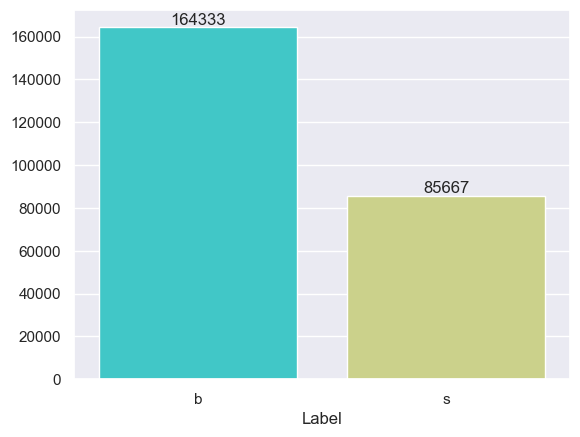

In [147]:
#plot target column
# plt.figure(figsize=(12,3))
ax = sns.barplot(x=df['Label'].value_counts().index,y=df['Label'].value_counts().values,palette='rainbow')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
# plt.savefig('TargetColumn.png')
plt.show()

In [148]:
#understand categorical columns
print(df['PRI_jet_num'].value_counts())

PRI_jet_num
0    99913
1    77544
2    50379
3    22164
Name: count, dtype: int64


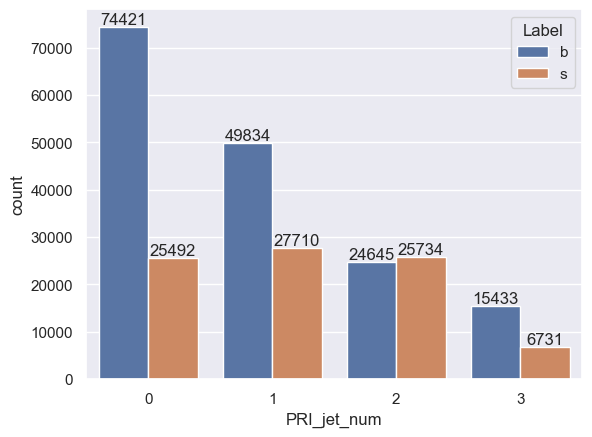

In [149]:
ax = sns.countplot(x='PRI_jet_num', data=df, hue='Label')
for container in ax.containers:
    ax.bar_label(container)
plt.show()

### Observation:
1. For PRI_jet_num 0, there are significantaly more noice than actual signals
2. For PRI_jet_num 2, there are little more actual signals then noice
3. For PRI_jet_num 1 and 3, noices are more

In [151]:
#understand numnerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
EventId,250000.0,224999.500000,72168.927986,100000.000000,162499.750000,224999.500000,287499.250000,349999.000000
DER_mass_transverse_met_lep,250000.0,49.239819,35.344886,0.000000,19.241000,46.524000,73.598000,690.075000
DER_mass_vis,250000.0,81.181982,40.828691,6.329000,59.388750,73.752000,92.259000,1349.351000
DER_pt_h,250000.0,57.895962,63.655682,0.000000,14.068750,38.467500,79.169000,2834.999000
DER_deltar_tau_lep,250000.0,2.373100,0.782911,0.208000,1.810000,2.491500,2.961000,5.684000
DER_pt_tot,250000.0,18.917332,22.273494,0.000000,2.841000,12.315500,27.591000,2834.999000
DER_sum_pt,250000.0,158.432217,115.706115,46.104000,77.550000,120.664500,200.478250,1852.462000
DER_pt_ratio_lep_tau,250000.0,1.437609,0.844743,0.047000,0.883000,1.280000,1.777000,19.773000
DER_met_phi_centrality,250000.0,-0.128305,1.193585,-1.414000,-1.371000,-0.356000,1.225000,1.414000
PRI_tau_pt,250000.0,38.707419,22.412081,20.000000,24.591750,31.804000,45.017000,764.408000


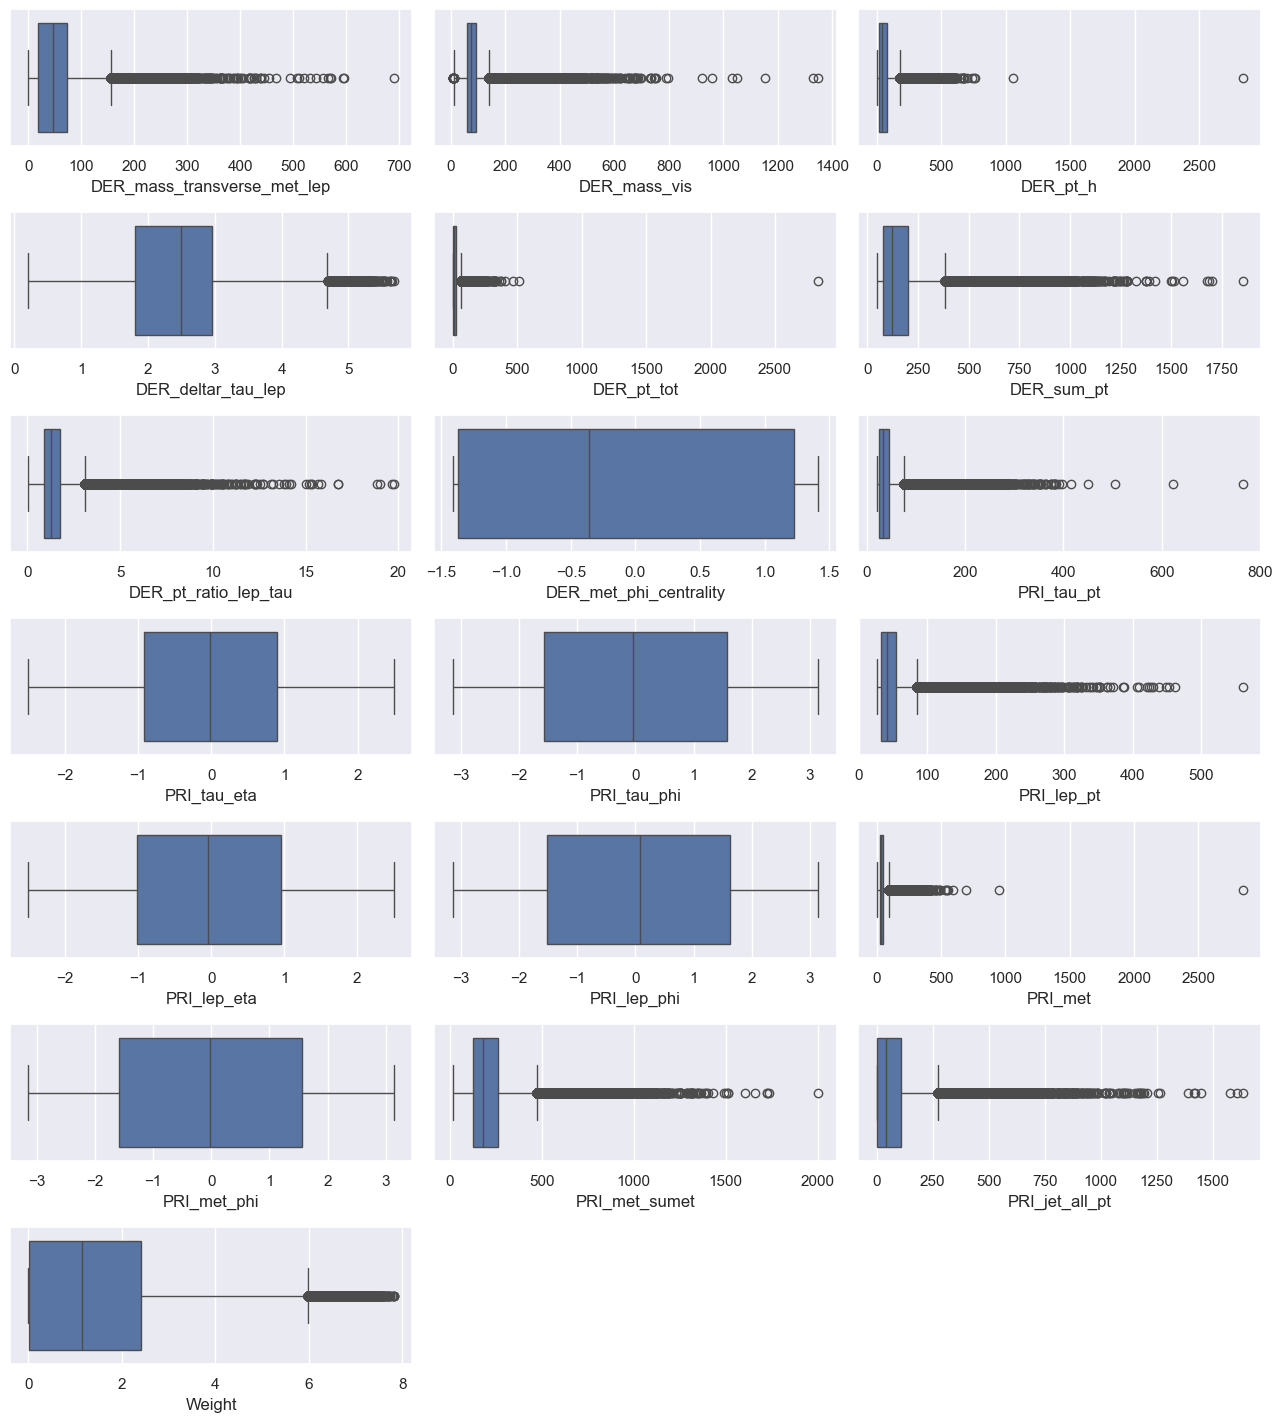

In [152]:
numerical_fields = df.drop(columns=['Label','EventId','PRI_jet_num'],axis=1)
i = 1
plt.figure(figsize=(13,20))
for col in numerical_fields.columns:
        plt.subplot(10,3,i)
        sns.boxplot(x=numerical_fields[col])
        # plt.title(f'Distribution of {col}')
        i +=1

plt.tight_layout()
# plt.savefig('Outlier.png')
plt.show()

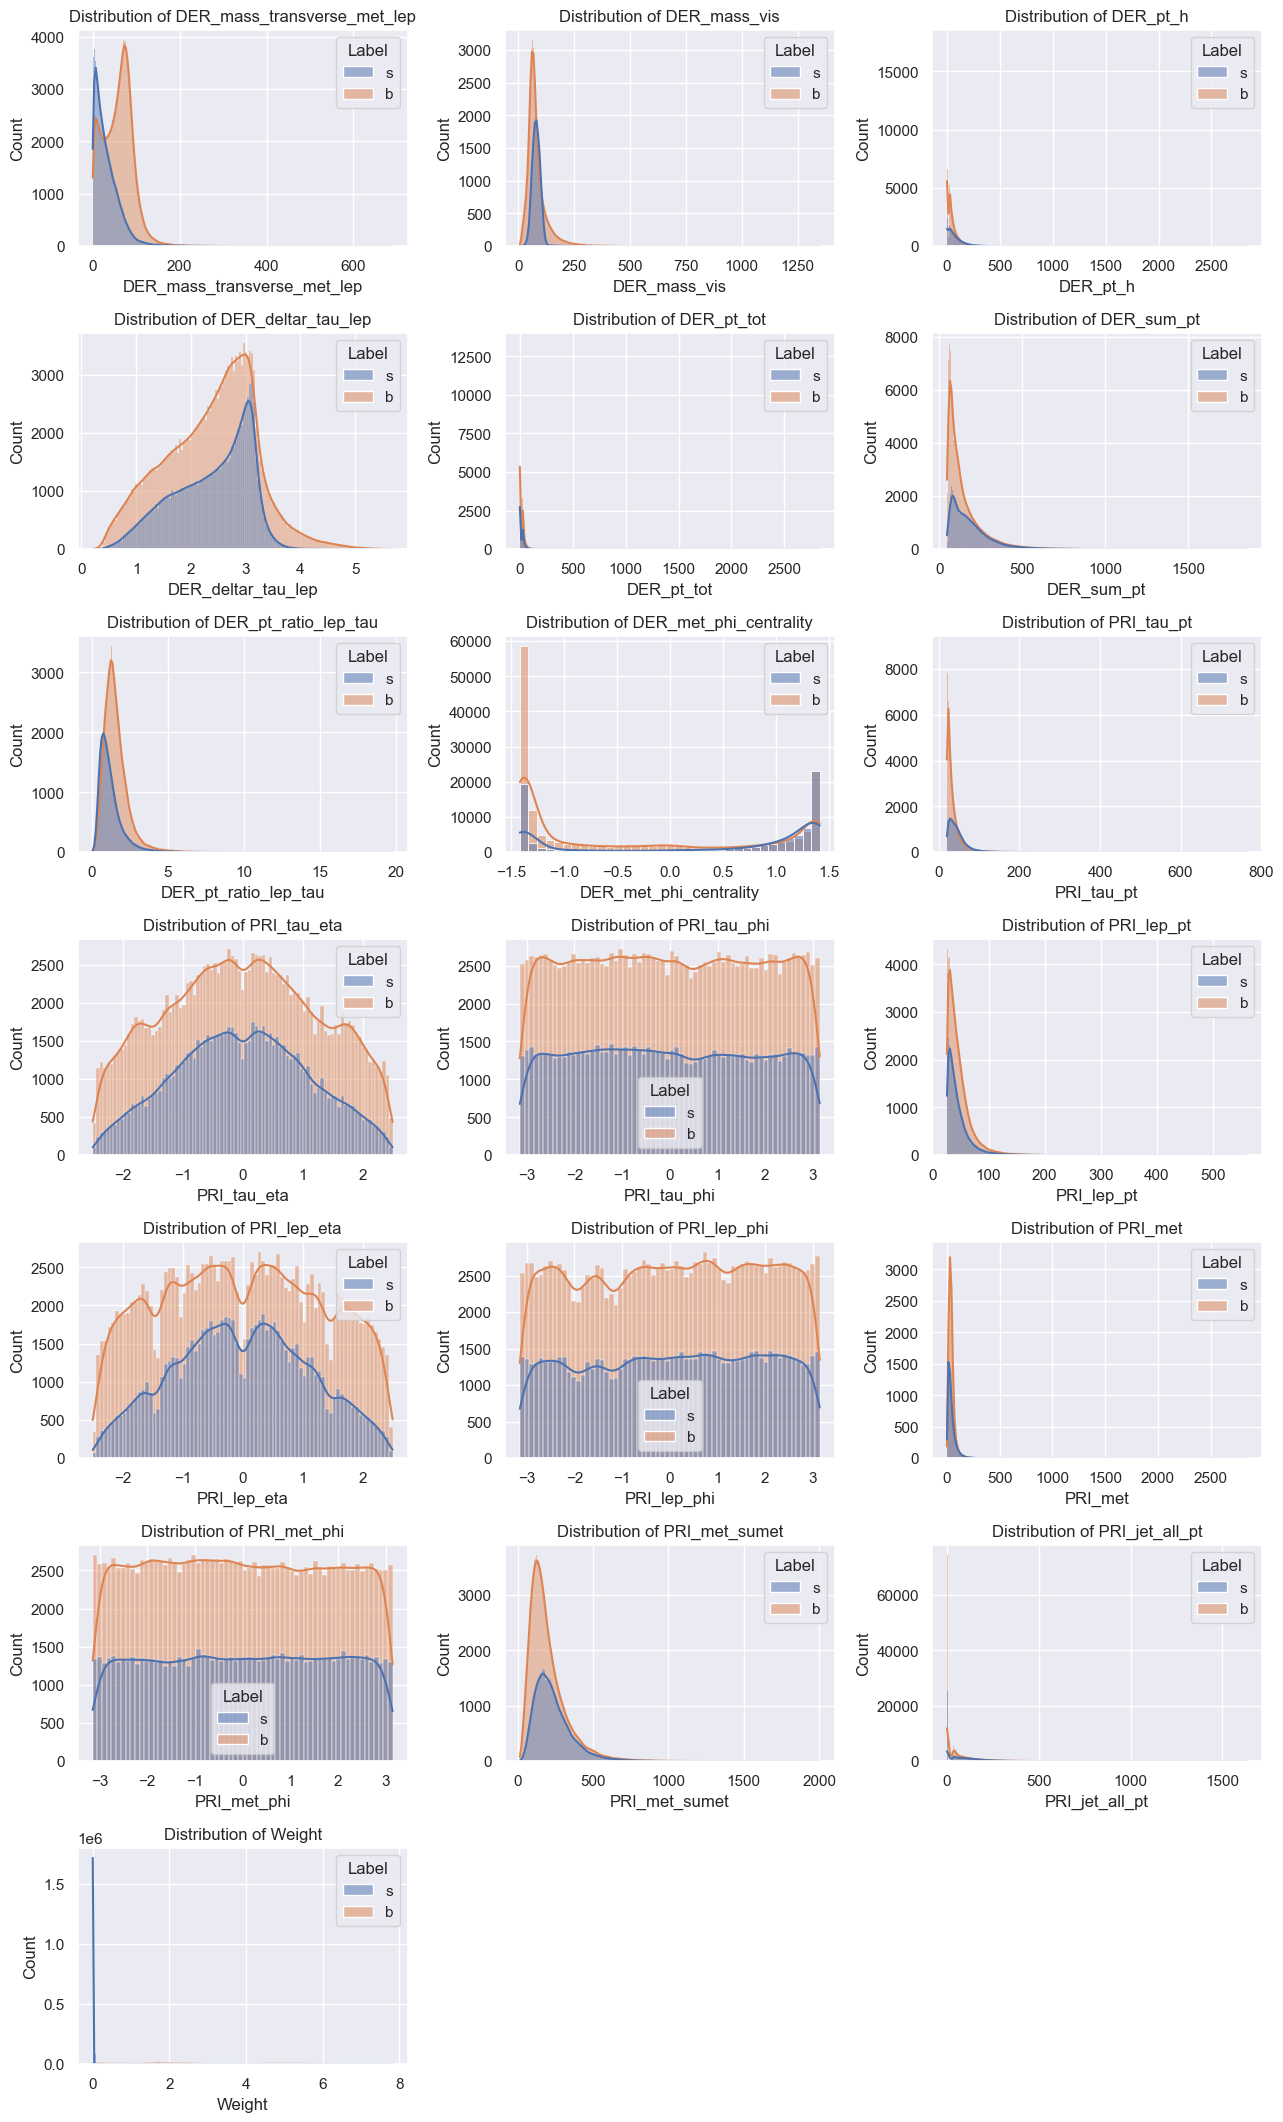

In [153]:
plt.figure(figsize=(13,30))
i=1
for col in numerical_fields.columns:
    plt.subplot(10, 3, i)
    sns.histplot(x=numerical_fields[col],kde=True,hue=df['Label'])
    plt.title(f'Distribution of {col}')
    i +=1

plt.tight_layout()
# plt.savefig('NumericalFeatures_small.png')
plt.show()

In [154]:
#handling outliers
for col in numerical_fields.columns:
    Q1 = df[col].quantile(0.25)
    Q2 = df[col].quantile(0.5)  #numerical_fields[col].mean()
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    lower_bound = Q1-1.5*IQR
    upper_bound = Q3+1.5*IQR
    df[col] = df[col].apply(lambda x: upper_bound if x > upper_bound else (lower_bound if x < lower_bound else x))

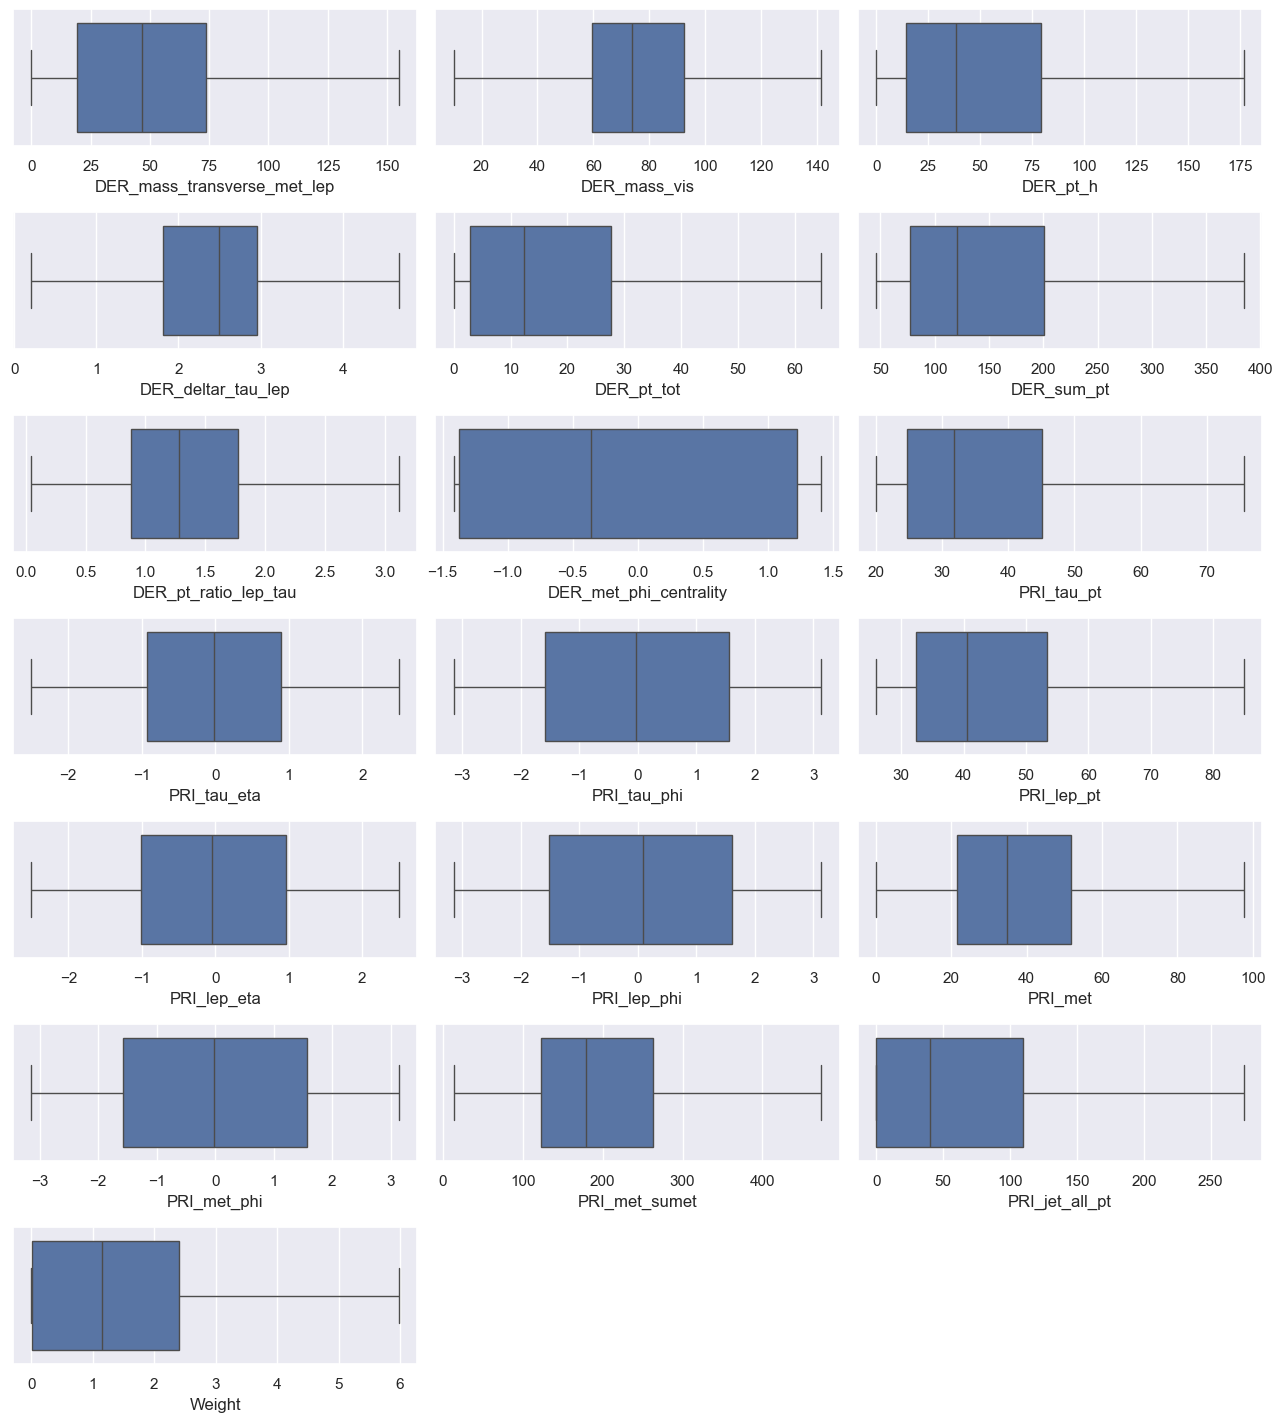

In [155]:
#boxplot after outlier treatment
numerical_fields = df.drop(columns=['Label','EventId','PRI_jet_num'],axis=1)
i = 1
plt.figure(figsize=(13,20))
for col in numerical_fields.columns:
        plt.subplot(10,3,i)
        sns.boxplot(x=numerical_fields[col])
        # plt.title(f'Distribution of {col}')
        i +=1

plt.tight_layout()
# plt.savefig('Outlier.png')
plt.show()

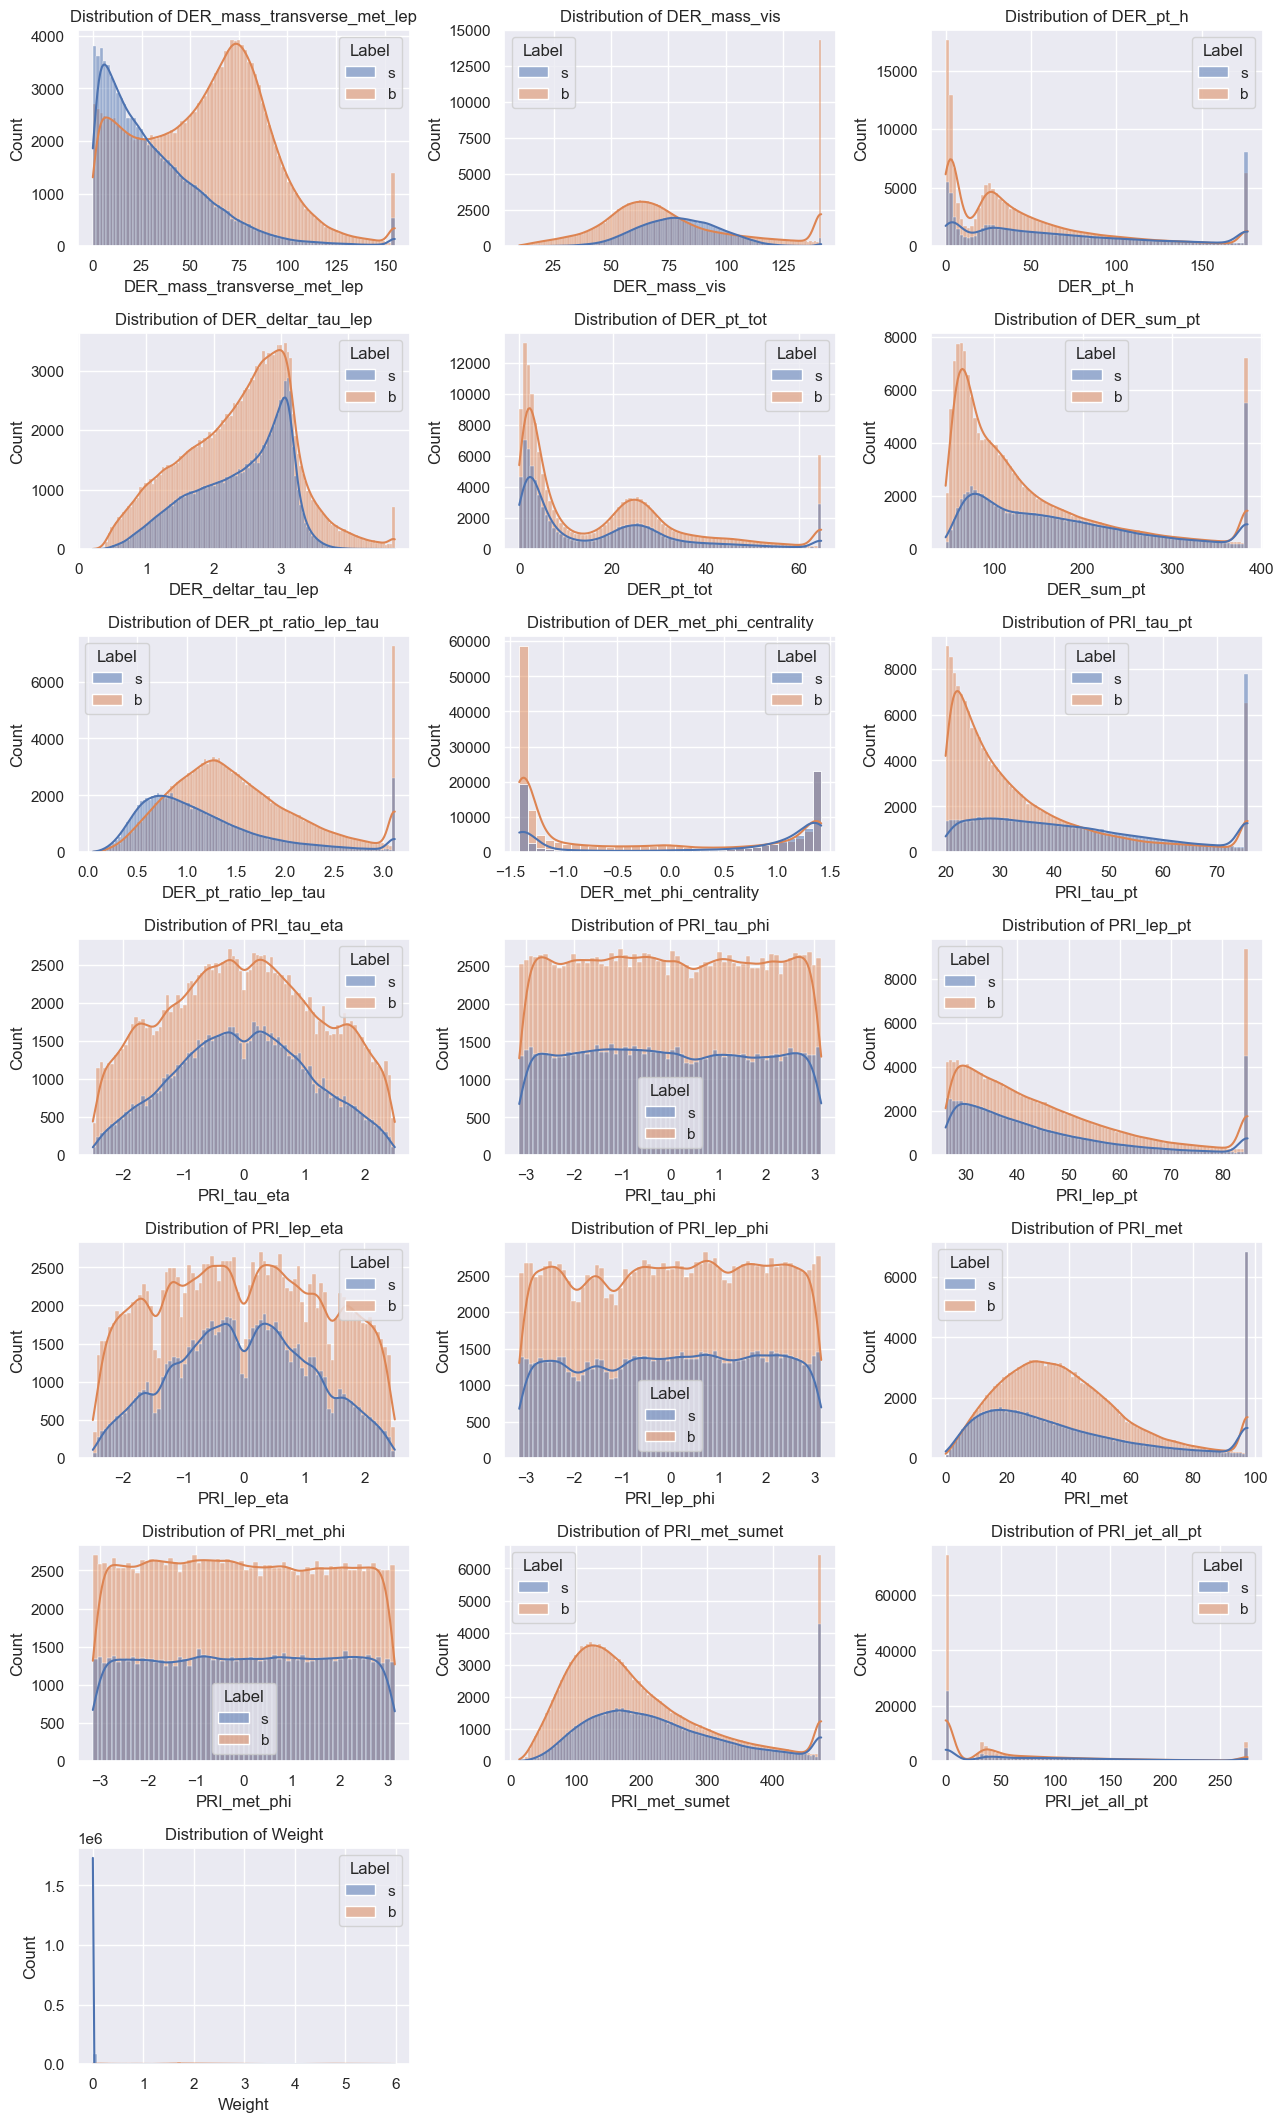

In [156]:
plt.figure(figsize=(13,30))
i=1
for col in numerical_fields.columns:
    plt.subplot(10, 3, i)
    # if col in (['Age', 'Flight Distance', 'Departure Delay', 'Arrival Delay']):
    sns.histplot(x=numerical_fields[col],kde=True,hue=df['Label'])
    # else:
    #     sns.histplot(x=numerical_fields[col])
    plt.title(f'Distribution of {col}')
    i +=1

plt.tight_layout()
# plt.savefig('NumericalFeatures_small.png')
plt.show()

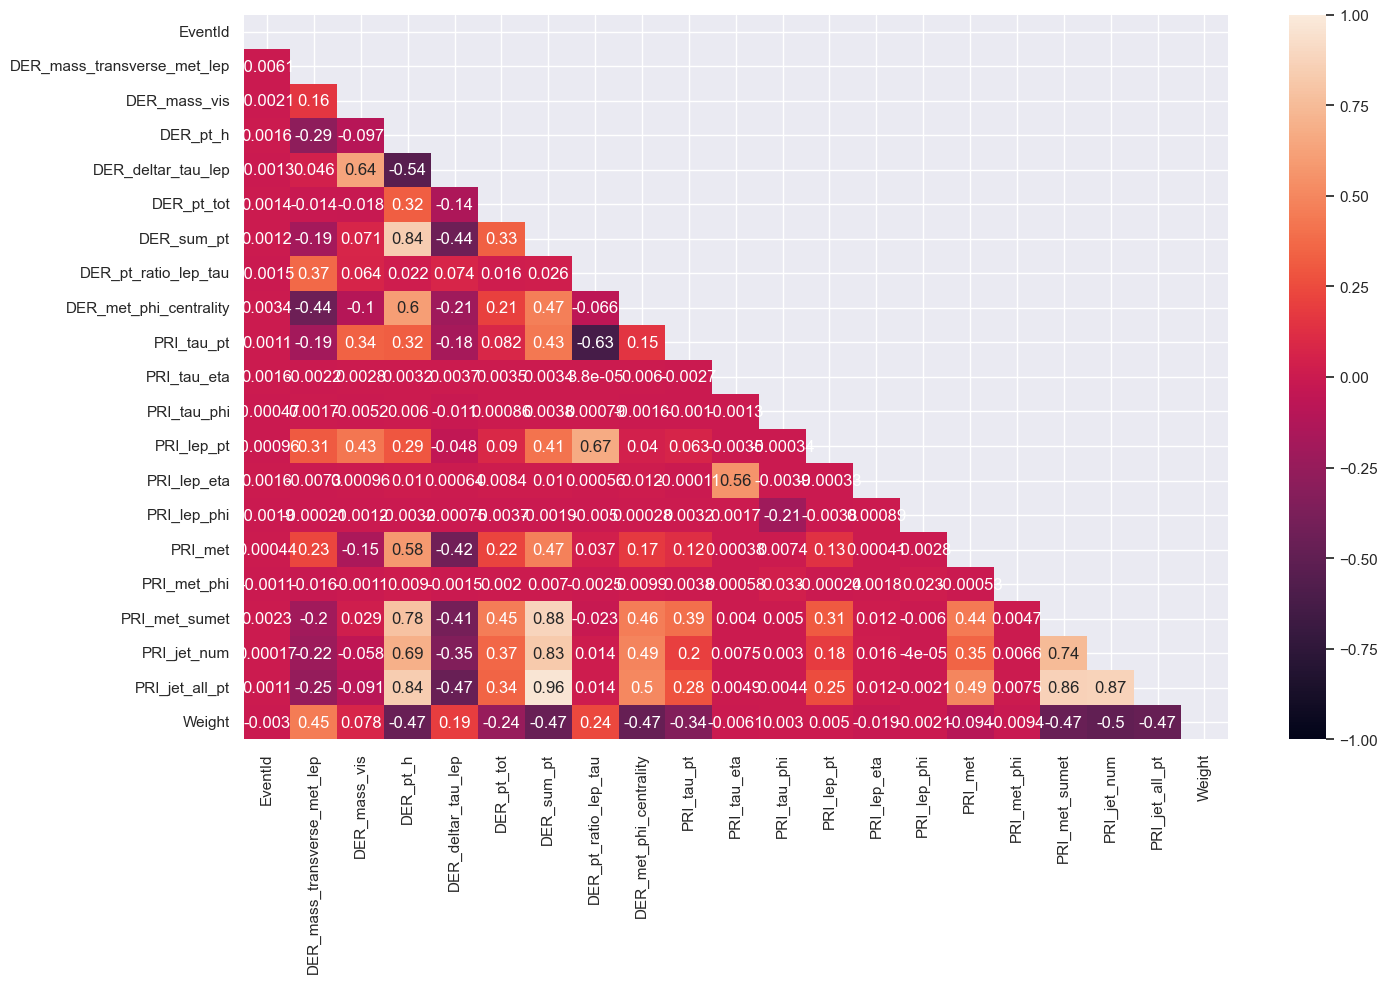

In [157]:
# heat map
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True),vmin=-1,vmax=1,annot=True,mask=np.triu(df.corr(numeric_only=True)))
plt.tight_layout()
plt.show()

### Observation:
1. DER_pt_h, DER_sum_pt, PRI_met_sumet and PRI_jet_num coolumns are highly correlated with other columns, better to drop this columns to avid multicolinearity

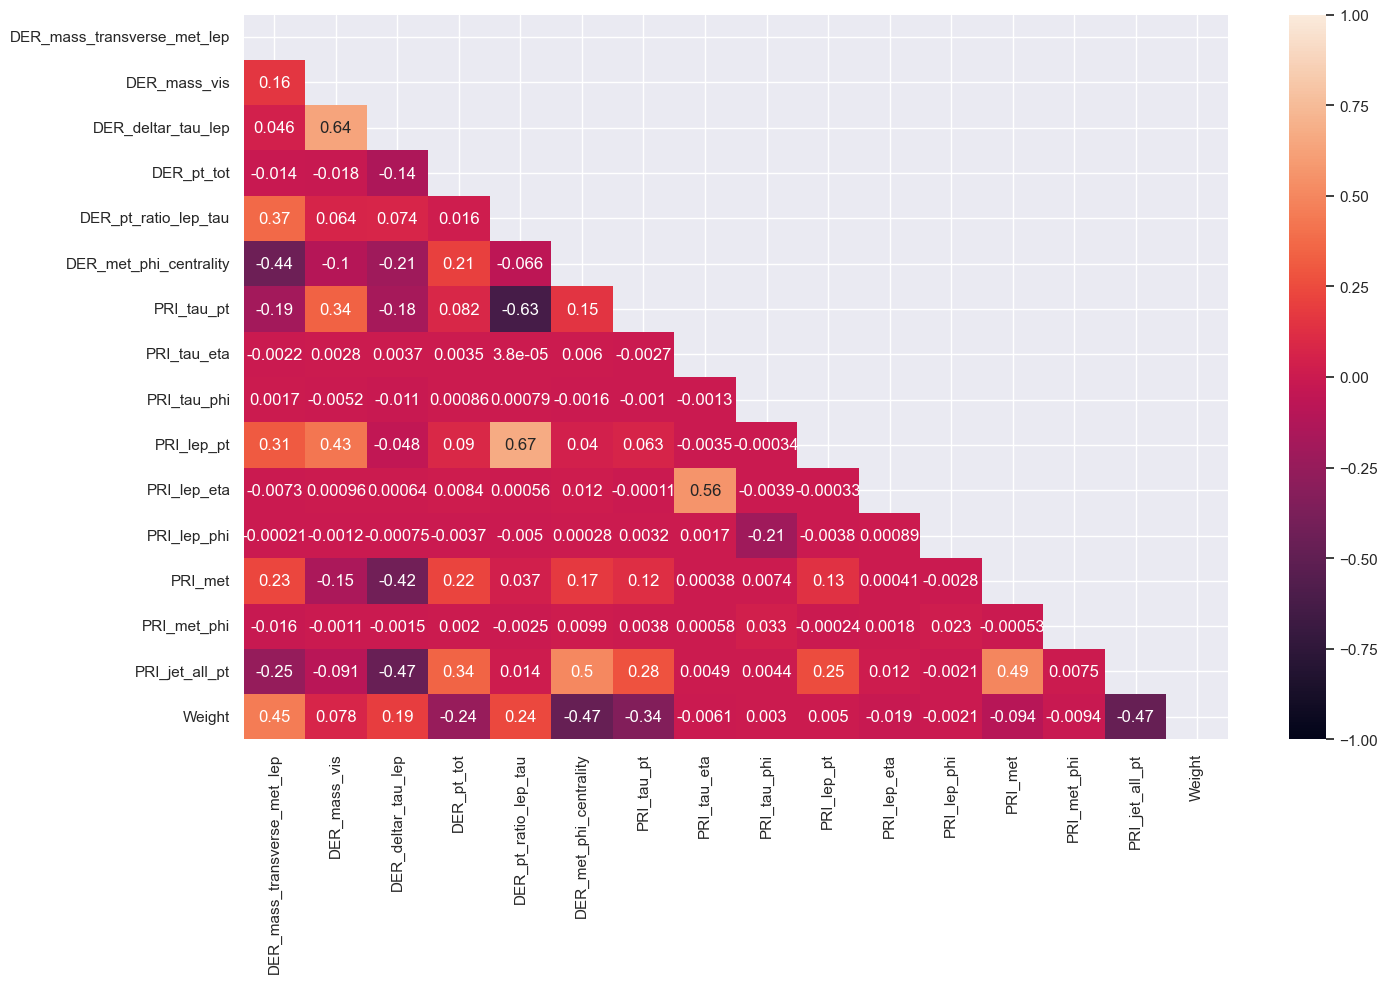

In [159]:
df.drop(['EventId','DER_pt_h', 'DER_sum_pt', 'PRI_met_sumet', 'PRI_jet_num'],axis=1, inplace=True)
# heat map after treatment
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True),vmin=-1,vmax=1,annot=True,mask=np.triu(df.corr(numeric_only=True)))
plt.tight_layout()
plt.show()

### Data Leak

In [161]:
#remove weight feature as it reason for data leak
# <0.06 Weights are 's' and >=0.06 are 'b'
df.drop(['Weight'],axis=1, inplace=True)

In [162]:
df.shape

(250000, 16)

## Data Preprocessing

In [164]:
#categorical features

print(col,': ',df['Label'].value_counts(normalize=True)*100)

Weight :  Label
b    65.7332
s    34.2668
Name: proportion, dtype: float64


In [165]:
#encoding of categorical data
df['Label'] = df['Label'].map({'b':0,'s':1})

print(col,': ',df['Label'].value_counts(normalize=True)*100)

Weight :  Label
0    65.7332
1    34.2668
Name: proportion, dtype: float64


In [166]:
#train test split
x = df.drop(columns=['Label'], axis=1)
y = df['Label']

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42, stratify=y)

#data dimension of train and test
print('x_train: ',x_train.shape)
print('y_train: ',y_train.shape)
print('x_test: ',x_test.shape)
print('y_test: ',y_test.shape)

x_train:  (200000, 15)
y_train:  (200000,)
x_test:  (50000, 15)
y_test:  (50000,)


In [167]:
#standerdization
std_scale = StandardScaler()

x_train_scaled = std_scale.fit_transform(x_train)
x_train_scaled_df = pd.DataFrame(x_train_scaled,columns=std_scale.get_feature_names_out())

x_test_scaled = std_scale.transform(x_test)
x_test_scaled_df = pd.DataFrame(x_test_scaled,columns=std_scale.get_feature_names_out())

x_train_scaled_df.head()

,DER_mass_transverse_met_lep,DER_mass_vis,DER_deltar_tau_lep,DER_pt_tot,DER_pt_ratio_lep_tau,DER_met_phi_centrality,PRI_tau_pt,PRI_tau_eta,PRI_tau_phi,PRI_lep_pt,PRI_lep_eta,PRI_lep_phi,PRI_met,PRI_met_phi,PRI_jet_all_pt
0,-1.163500,1.139513,1.149889,-0.994851,-0.830243,1.288341,0.911356,0.907265,1.192567,-0.158441,1.777816,-0.521572,-1.047169,-0.272873,0.254899
1,-1.111938,-0.555996,0.634622,-0.854130,0.211132,1.246457,-0.848852,-1.363573,0.971421,-0.533292,-0.675065,-0.997416,-0.720923,-1.195570,-0.398505
2,-0.694323,-0.655911,1.217822,-0.785912,-0.448649,1.291692,-0.817285,-1.361102,0.038974,-1.161685,-0.354231,-1.696312,-0.429507,-1.140418,-0.408413
3,0.803877,1.619549,0.724345,0.257413,-0.833156,-0.033525,0.275706,1.190605,-0.499040,-0.677071,-0.668744,-1.534393,0.255618,-0.085906,0.245375
4,-0.582324,-0.807146,0.439794,-0.832648,-0.214157,1.276614,-0.740839,0.887497,-0.938583,-0.827949,0.945701,0.527597,0.638422,0.161176,1.629305


## Model Building

In [169]:
model_names = []
model_train_acc = []
model_test_acc = []
precision_acc = []
recall_acc = []
f1_acc = []
result_df = {}

In [170]:
model = DecisionTreeClassifier(random_state=42,class_weight='balanced')
model.fit(x_train_scaled_df, y_train)
train_score = model.score(x_train_scaled_df, y_train)
y_pred = model.predict(x_test_scaled_df)

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
model_names.append('DecisionTreeClassifier')
model_train_acc.append(train_score)
model_test_acc.append(acc)
precision_acc.append(precision)
recall_acc.append(recall)
f1_acc.append(f1)

In [171]:
model = RandomForestClassifier(random_state=42, class_weight='balanced')
model.fit(x_train_scaled_df, y_train)
train_score = model.score(x_train_scaled_df, y_train)
y_pred = model.predict(x_test_scaled_df)

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
model_names.append('RandomForestClassifier')
model_train_acc.append(train_score)
model_test_acc.append(acc)
precision_acc.append(precision)
recall_acc.append(recall)
f1_acc.append(f1)

In [172]:
model = LogisticRegression(random_state=42, class_weight='balanced')
model.fit(x_train_scaled_df, y_train)
train_score = model.score(x_train_scaled_df, y_train)
y_pred = model.predict(x_test_scaled_df)

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
model_names.append('LogisticRegression')
model_train_acc.append(train_score)
model_test_acc.append(acc)
precision_acc.append(precision)
recall_acc.append(recall)
f1_acc.append(f1)

In [173]:

model = GaussianNB()
model.fit(x_train_scaled_df, y_train)
train_score = model.score(x_train_scaled_df, y_train)
y_pred = model.predict(x_test_scaled_df)

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
model_names.append('GaussianNB')
model_train_acc.append(train_score)
model_test_acc.append(acc)
precision_acc.append(precision)
recall_acc.append(recall)
f1_acc.append(f1)

In [174]:

model = LGBMClassifier(random_state=42)
model.fit(x_train_scaled_df, y_train)
train_score = model.score(x_train_scaled_df, y_train)
y_pred = model.predict(x_test_scaled_df)

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
model_names.append('LGBMClassifier')
model_train_acc.append(train_score)
model_test_acc.append(acc)
precision_acc.append(precision)
recall_acc.append(recall)
f1_acc.append(f1)

[LightGBM] [Info] Number of positive: 68534, number of negative: 131466
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019582 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3822
[LightGBM] [Info] Number of data points in the train set: 200000, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.342670 -> initscore=-0.651418
[LightGBM] [Info] Start training from score -0.651418


In [175]:

model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(x_train_scaled_df, y_train)
train_score = model.score(x_train_scaled_df, y_train)
y_pred = model.predict(x_test_scaled_df)

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
model_names.append('XGBClassifier')
model_train_acc.append(train_score)
model_test_acc.append(acc)
precision_acc.append(precision)
recall_acc.append(recall)
f1_acc.append(f1)

In [176]:
result_df = {
    'Model_name' : model_names,
    'Train_acc' : model_train_acc,
    'Test_acc' : model_test_acc,
    'Precision_acc' : precision_acc,
    'Recall_acc' : recall_acc,
    'f1_score' : f1_acc
}
result_df = pd.DataFrame(result_df)

In [177]:
result_df

,Model_name,Train_acc,Test_acc,Precision_acc,Recall_acc,f1_score
0,DecisionTreeClassifier,1.000000,0.75048,0.636963,0.632055,0.634499
1,RandomForestClassifier,0.999990,0.82294,0.782478,0.669352,0.721507
2,LogisticRegression,0.718195,0.71708,0.566316,0.744411,0.643264
3,GaussianNB,0.745630,0.74270,0.618846,0.648573,0.633361
4,LGBMClassifier,0.832245,0.82546,0.765341,0.707582,0.735329
5,XGBClassifier,0.849515,0.82444,0.761765,0.709566,0.734740


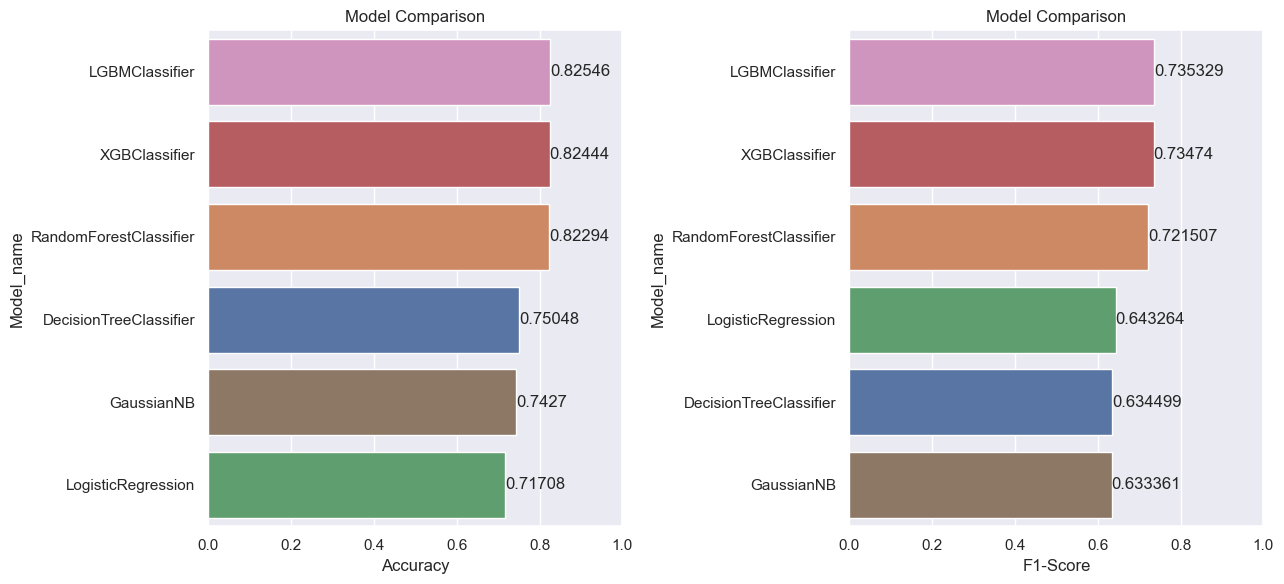

In [178]:
plt.figure(figsize=(13, 6))
custom_palette = {
    "DecisionTreeClassifier": "#4c72b0",          # deep blue
    "RandomForestClassifier": "#dd8452",          # orange
    "LogisticRegression": "#55a868",     # green
    "SVC": "#8172b3",     # purple
    "GaussianNB": "#937860", # brown
    "LGBMClassifier": "#da8bc3",       # pink
    "XGBClassifier": "#c44e52",           # red
}


plt.subplot(1,2,1)
ax = sns.barplot(x='Test_acc', y='Model_name',data=result_df.sort_values(by='Test_acc', ascending=False), palette=custom_palette)
for i in ax.containers:
    plt.bar_label(i)
plt.xlabel("Accuracy")
plt.title("Model Comparison")
plt.xlim(0, 1)

plt.subplot(1,2,2)
ax = sns.barplot(x='f1_score', y='Model_name',data=result_df.sort_values(by='f1_score', ascending=False), palette=custom_palette)
for i in ax.containers:
    plt.bar_label(i)
plt.xlabel("F1-Score")
plt.title("Model Comparison")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()


### Observation :
1. DecisionTree: Severe overfitting (Train=1.0, Test=0.75).
2. RandomForest: Strong accuracy (0.82) with high precision but lower recall.
3. LogisticRegression: Moderate accuracy, high recall but low precision.
4. GaussianNB: Similar to LogisticRegression, overall weaker.
5. LGBM & XGB: Best balance, stable performance (~0.825 Test acc, good F1), no overfitting.

[LightGBM] [Info] Number of positive: 68534, number of negative: 131466
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020506 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3822
[LightGBM] [Info] Number of data points in the train set: 200000, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
              precision    recall  f1-score   support

           0       0.90      0.79      0.84     32867
           1       0.68      0.82      0.74     17133

    accuracy                           0.80     50000
   macro avg       0.79      0.81      0.79     50000
weighted avg       0.82      0.80      0.81     50000

Train Accuracy: 0.65733
Test Accuracy: 0.8049
precision: 0.6768625946878896
recall: 0.8240238136928734
f1: 0.7432286594193361


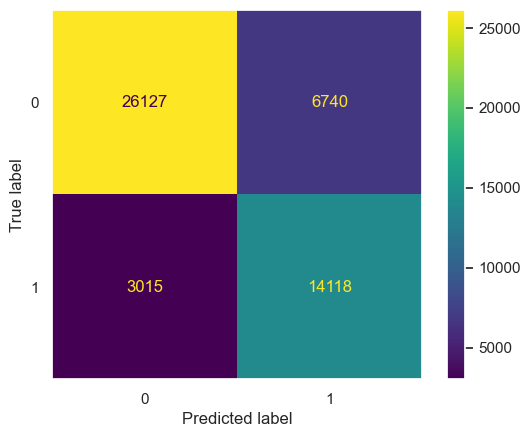

In [180]:
#LightGBM

lgb = LGBMClassifier(random_state=42,learning_rate=0.06, class_weight ='balanced')
lgb.fit(x_train_scaled_df, y_train)
y_pred = lgb.predict(x_test_scaled_df)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


print(classification_report(y_test, y_pred))
print('Train Accuracy:',lgb.score(x_train, y_train))
print('Test Accuracy:',accuracy_score(y_test, y_pred))
print('precision:',precision)
print('recall:',recall)
print('f1:',f1)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.grid(False)

## Hyperparameter tunning

In [182]:
from sklearn.model_selection import GridSearchCV

# Base model
lgb = LGBMClassifier(random_state=42,class_weight ='balanced')

# Define parameter grid
param_grid = {
    'max_depth': [-1, 5, 10, 20],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 500]
}

# Grid Search
grid = GridSearchCV(estimator=lgb, 
                    param_grid=param_grid, 
                    scoring='recall',   
                    cv=5,
                    verbose=1,
                    n_jobs=-1)

grid.fit(x_train_scaled_df, y_train)


Fitting 5 folds for each of 36 candidates, totalling 180 fits
[LightGBM] [Info] Number of positive: 68534, number of negative: 131466
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020217 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3822
[LightGBM] [Info] Number of data points in the train set: 200000, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

GridSearchCV(cv=5,
             estimator=LGBMClassifier(class_weight='balanced', random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [-1, 5, 10, 20],
                         'n_estimators': [100, 200, 500]},
             scoring='recall', verbose=1)

In [183]:
print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best Score: 0.8264657027374019


In [184]:
# Building the final model with the best parameter from grid search
best_parameters = grid.best_params_
final_model = LGBMClassifier(**best_parameters, random_state=42,class_weight ='balanced')

# fit the data onto the final model
final_model.fit(x_train_scaled_df, y_train)

# model score
print('Training Score:', round(final_model.score(x_train_scaled_df, y_train)*100,2), '%')

[LightGBM] [Info] Number of positive: 68534, number of negative: 131466
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.035650 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3822
[LightGBM] [Info] Number of data points in the train set: 200000, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

In [185]:
# Testing our model
y_pred_final = final_model.predict(x_test_scaled_df)

# metrics
print('Testing Score', round(accuracy_score(y_test, y_pred_final)*100, 2), '%')

Testing Score 80.87 %


Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.80      0.85     32867
           1       0.68      0.83      0.75     17133

    accuracy                           0.81     50000
   macro avg       0.79      0.81      0.80     50000
weighted avg       0.82      0.81      0.81     50000



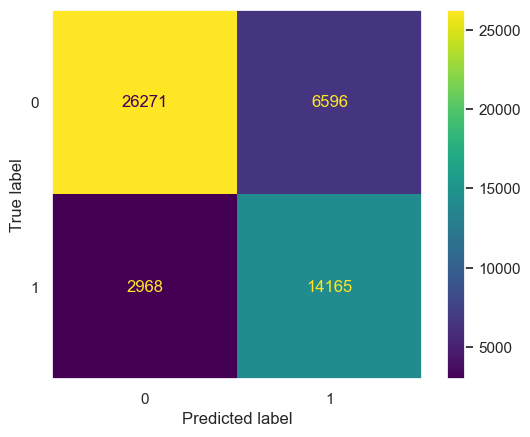

In [186]:
# Detailed metrics
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final)
print('Classification Report:\n', classification_report(y_test, y_pred_final))
plt.grid(False)

In [ ]:
TP = 14165
TN = 26271
FP = 6596
FN = 2968

accuracy = (TP+TN)/(TP+TN+FP+FN)

recall = (TP)/(TP+FN)
precesin = TP/(TP+FP)


In [187]:
# Computing the AUC-ROC
fpr, tpr, thr = roc_curve(y_test, y_pred_final)
auc = roc_auc_score(y_test, y_pred_final)
print('Area under the roc curve:', round(auc*100, 2), '%')

Area under the roc curve: 81.3 %


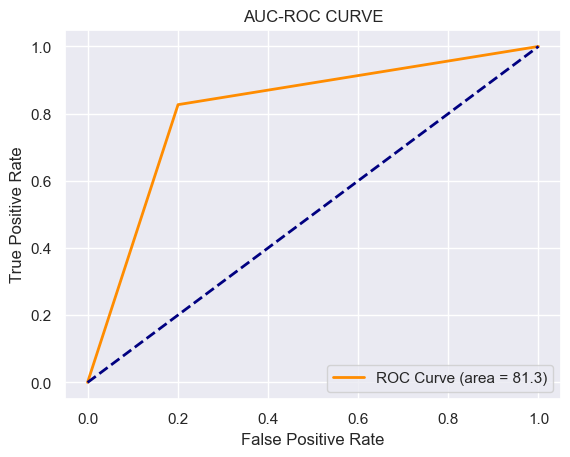

In [188]:
# Plotting the AUC ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (area = {round(auc*100, 2)})')
plt.plot([0,1], [0,1], color='navy', lw=2, ls='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC CURVE')
plt.legend(loc=4)
plt.show()

In [189]:
imp = final_model.feature_importances_
col_names = x_train_scaled_df.columns

fet_imp = pd.DataFrame({'feature':col_names,'importance':imp})
fet_imp = fet_imp.sort_values(by='importance',ascending=False)
fet_imp['importance(%)'] = 100* fet_imp['importance']/fet_imp['importance'].sum()
fet_imp['cummulative(%)'] = fet_imp['importance(%)'].cumsum()
fet_imp

,feature,importance,importance(%),cummulative(%)
1,DER_mass_vis,809,13.912296,13.912296
2,DER_deltar_tau_lep,677,11.642304,25.554600
12,PRI_met,675,11.607911,37.162511
0,DER_mass_transverse_met_lep,543,9.337919,46.500430
3,DER_pt_tot,459,7.893379,54.393809
14,PRI_jet_all_pt,444,7.635426,62.029235
5,DER_met_phi_centrality,428,7.360275,69.389510
7,PRI_tau_eta,306,5.262253,74.651763
6,PRI_tau_pt,300,5.159071,79.810834
10,PRI_lep_eta,277,4.763543,84.574377


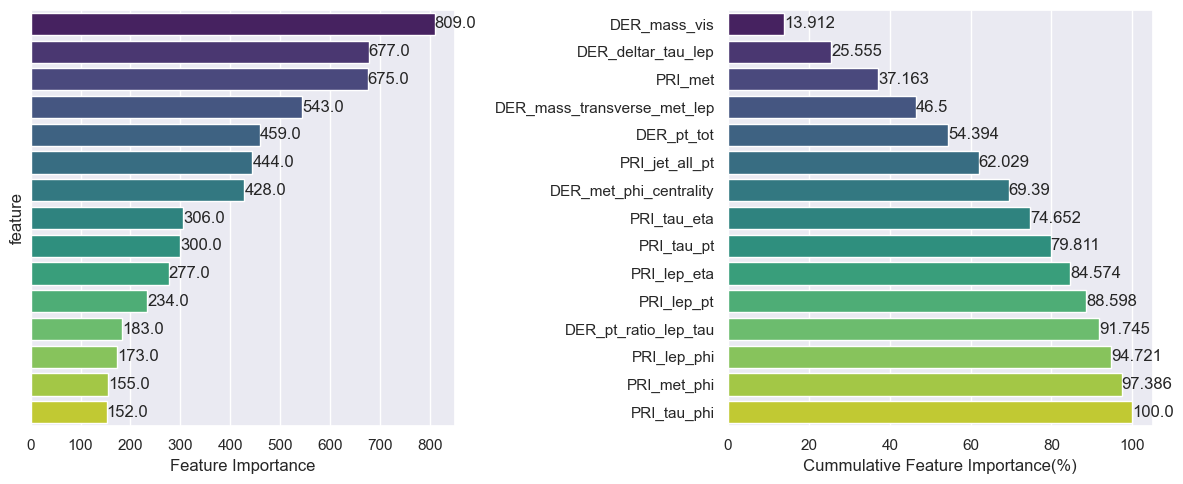

In [190]:
# Plotting Feature Importance
plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
ax1=sns.barplot(x='importance', y='feature', data=fet_imp, palette='viridis')
for i in ax1.containers:
    plt.bar_label(i,fmt=lambda x: f'{round(x,3)}')
plt.yticks([])
plt.xlabel('Feature Importance')


plt.subplot(1,2,2)
ax2=sns.barplot(x='cummulative(%)', y='feature', data=fet_imp, palette='viridis')
for i in ax2.containers:
    plt.bar_label(i,fmt=lambda x: f'{round(x,3)}')
plt.ylabel('')
plt.xlabel('Cummulative Feature Importance(%)')

plt.tight_layout()
plt.show()